In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

In [51]:
adata = sc.read_h5ad('zheng_pbmc_all.h5ad')
adata.var.index = adata.var['gene_symbols'].astype(str).values
adata

/data1/miniconda3/envs/research/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 87193 × 18718
    obs: 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [52]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
adata

AnnData object with n_obs × n_vars = 87193 × 18718
    obs: 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [53]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [54]:
adata = adata[adata.obs['pct_counts_mt'] < 10, :].copy()          # keep <10% mitochondrial reads

/data1/miniconda3/envs/research/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [55]:
sc.pp.filter_cells(adata, min_genes=100)
# sc.pp.filter_genes(adata, min_cells=3)

In [48]:
adata.obs['cell_type'].value_counts()

cell_type
CD8+/CD45RA+ Naive Cytotoxic    11952
CD4+ T Helper2                  11209
CD4+/CD45RA+/CD25- Naive T      10477
CD4+/CD25 T Reg                 10256
CD4+/CD45RO+ Memory             10222
CD8+ Cytotoxic T                10207
CD19+ B                         10068
CD56+ NK                         8351
CD34+                            3779
CD14+ Monocyte                    576
Dendritic                          96
Name: count, dtype: int64

In [56]:
adata = adata[adata.obs["cell_type"].isin(['CD8+/CD45RA+ Naive Cytotoxic', 'CD4+/CD45RA+/CD25- Naive T',
                                            'CD19+ B', 'CD56+ NK', 'CD34+'])]
# adata = adata[adata.obs["cell_type"].isin(['CD4+ T Helper2', 'CD4+/CD45RA+/CD25- Naive T',
#                                             'CD4+/CD25 T Reg', 'CD4+/CD45RO+ Memory'])]

adata.var_names_make_unique()
adata = adata[adata.obs.sort_values("cell_type").index]
adata

/data1/miniconda3/envs/research/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


View of AnnData object with n_obs × n_vars = 44627 × 18718
    obs: 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [57]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

/data1/miniconda3/envs/research/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [77]:
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
adata = adata[:, adata.var['highly_variable']].copy()
hvg_genes = adata.var[adata.var['highly_variable']].index.to_list()
pd.Series(hvg_genes).to_csv(f"zheng_cd4_HVG1000_genes.csv", index=False, header=['gene'])
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1, flavor="igraph")
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')
markers = adata.uns['rank_genes_groups']
groups = markers['names'].dtype.names
top20_list = []
for g in groups:
    df = pd.DataFrame({g: markers['names'][g][:20]})
    top20_list.append(df)
top20 = pd.concat(top20_list, axis=1)
top20.to_csv(f"zheng_cd4_top20_genes.csv", index=False)

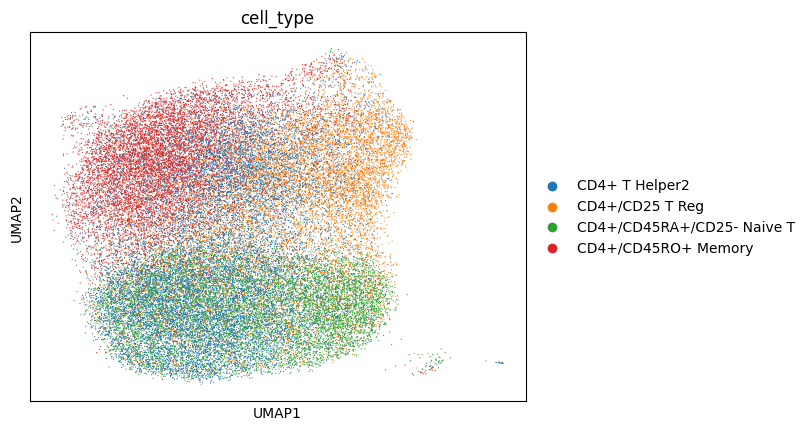

In [78]:
sc.pl.umap(
        adata,
        color=['cell_type'],
        # legend_loc="upper right",
        show=True,
        save=f"zheng_cd4.png"
    )